<span style="float: left;padding: 1.3em">![logo](https://github.com/gw-odw/odw/blob/main/Tutorials/logo.png?raw=1)</span>

# Gravitational Wave Open Data Workshop

## Tutorial 4.1: An introduction to matched-filtering

We will be using the [PyCBC](https://pycbc.org) library, which is used to study gravitational-wave data, find astrophysical sources due to compact binary mergers, and study their parameters. These are some of the same tools that the LIGO and Virgo collaborations use to find gravitational waves in LIGO/Virgo data

In this tutorial we will walk through how to find a specific signal in LIGO data. We present matched filtering as a cross-correlation, in both the time domain and the frequency domain. In the next tutorial (2.2), we use the method as encoded in PyCBC, which is optimal in the case of Gaussian noise and a known signal model. In reality our noise is not entirely Gaussian, and in practice we use a variety of techniques to separate signals from noise in addition to the use of the matched filter.

View this tutorial on [Google Colaboratory](https://colab.research.google.com/github/gw-odw/odw/blob/main/Tutorials/04_Searches/Tuto_4.1_Matched_filtering_introduction.ipynb) or launch [mybinder](https://mybinder.org/v2/gh/gw-odw/odw/HEAD).

See [additional examples](https://pycbc.org/pycbc/latest/html/#library-examples-and-interactive-tutorials) and [documentation](https://pycbc.org/pycbc/latest/html/index.html).

In [ ]:
# Those 2 lines are just to avoid some harmless warnings when importing packages
import warnings # Import the warnings module to manage warning messages
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio") # Ignore a specific warning message that might appear from swiglal

## Installation (execute only if running on a cloud platform, like Google Colab, or if you haven't done the installation already!)

> ⚠️ **Warning**: restart the runtime after running the cell below.
>
> To do so, click "Runtime" in the menu and choose "Restart and run all".
>
> You may see error messages but installation usually works.
> If you experience problems, please [report an issue](https://github.com/gw-odw/odw/issues).

In [2]:
# -- Use the following for Google Colab
# Install the necessary Python packages using pip in quiet mode (-q)
# lalsuite: A library for gravitational wave data analysis.
# PyCBC: A Python library for gravitational-wave data analysis, used by LIGO/Virgo.
# cryptography: A package providing cryptographic recipes and primitives.
! pip install -q 'lalsuite==7.25' 'PyCBC==2.10.0' 'cryptography==43.0.0'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 19.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages tha

## Matched-filtering: Finding well modelled signals in Gaussian noise

Matched filtering can be shown to be the optimal method for "detecting" _known_ signals in _Gaussian_ noise. We'll explore those two assumptions a little later, but for now let's demonstrate how this works.

Let's assume you have a stretch of noise, white noise to start:

In [ ]:
import numpy # Import the NumPy library for numerical operations, especially array manipulation
# The first import of matplotlib can take some time (especially on cloud platforms). This is normal.
import matplotlib.pyplot as plt # Import Matplotlib's pyplot module for plotting, aliasing it as 'plt'

# specify the sample rate.
# LIGO raw data is sampled at 16384 Hz (=2^14 samples/second).
# It captures signal frequency content up to f_Nyquist = 8192 Hz.
# Here, we will make the computation faster by sampling at a lower rate.
sample_rate = 1024 # Define the sampling rate in samples per second (Hz)
data_length = 1024 # Define the total duration of the data in seconds

# Generate a long stretch of white noise: the data series and the time series.
# Generate an array of random numbers from a standard normal (Gaussian) distribution.
# The size is sample_rate * data_length, meaning total number of data points.
data = numpy.random.normal(size=[sample_rate * data_length])
# Create a corresponding time array for the generated data.
# It goes from 0 up to data_length, with steps determined by the sample_rate.
times = numpy.arange(len(data)) / float(sample_rate)

And then let's add a gravitational wave signal to some random part of this data.

In [ ]:
from pycbc.waveform import get_td_waveform # Import the function to generate time-domain gravitational wave waveforms

# the "approximant" (jargon for parameterized waveform family).
# IMRPhenomD(a phenomenological Inspiral–Merger–Ringdown wafeform model) is defined in the frequency domain, but we'll get it in the time domain (td).
# It runs fast, but it doesn't include effects such as non-aligned component spin, or higher order modes.
apx = 'IMRPhenomD' # Define the approximant (waveform model) to be used

Reference for [IMRPhenomD](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.93.044006). You can specify [many parameters](https://pycbc.org/pycbc/latest/html/pycbc.waveform.html?highlight=get_td_waveform#pycbc.waveform.waveform.get_td_waveform), but here, we'll use defaults for everything except the masses.

`get_td_waveform` returns both $h_+$ and $h_{\times}$, but we'll only use $h_+$ for now.

In [ ]:
# Generate a time-domain gravitational wave waveform (h_plus and h_cross polarizations).
# We only need h_plus (hp1), so the second return value (h_cross) is discarded with '_'.
hp1, _ = get_td_waveform(approximant=apx, # Specify the waveform model ('IMRPhenomD')
                         mass1=10, # Mass of the first compact object in solar masses
                         mass2=10, # Mass of the second compact object in solar masses
                         delta_t=1.0/sample_rate, # Time step between samples, derived from the sample rate
                         f_lower=25) # Lower frequency cutoff for the waveform generation (Hz)

The amplitude of gravitational-wave signals is normally of order $10^{-20}$. To demonstrate our method on white noise with amplitude $O(1)$ we normalize our signal so the cross-correlation of the signal with itself will give a value of 1.

In this case we can interpret the cross-correlation of the signal with white noise as a signal-to-noise ratio.

In [ ]:
# Normalize the signal (hp1) so that its autocorrelation peak has a value of 1.
# This makes the cross-correlation values directly interpretable as a signal-to-noise ratio.
hp1 = hp1 / max(numpy.correlate(hp1, hp1, mode='full'))**0.5

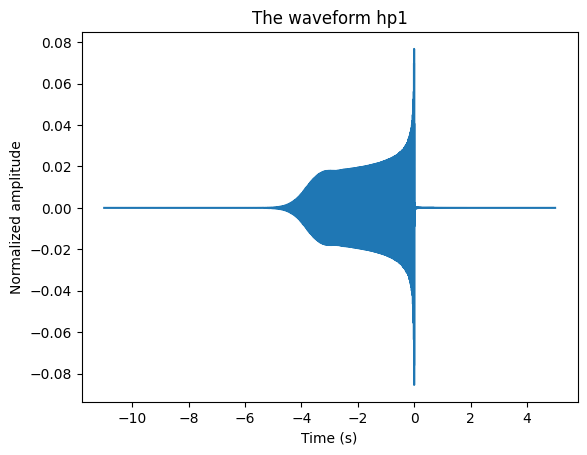

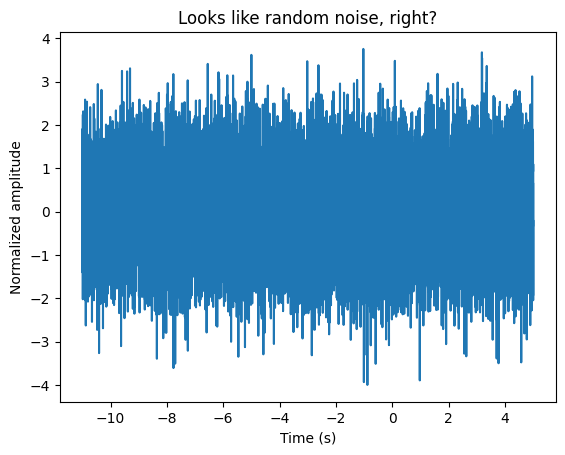

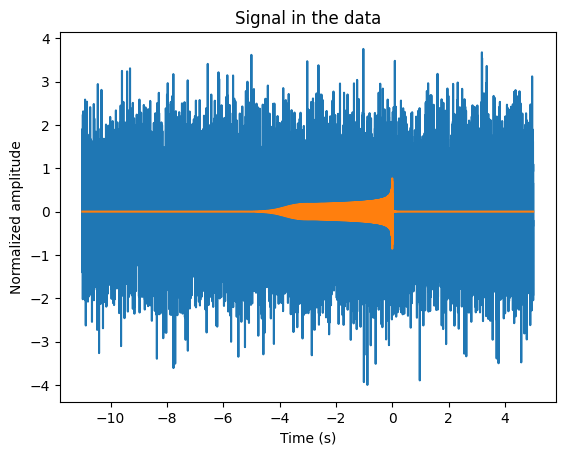

In [ ]:
# note that in this figure, the waveform amplitude is of order 1.
# The duration (for frequency above f_lower=25 Hz) is only 3 or 4 seconds long.
# The waveform is "tapered": slowly ramped up from zero to full strength, over the first second or so.
# It is zero-padded at earlier times.
plt.figure() # Create a new figure for plotting
plt.title("The waveform hp1") # Set the title of the first plot
plt.plot(hp1.sample_times, hp1) # Plot the waveform hp1 against its sample times
plt.xlabel('Time (s)') # Set the label for the x-axis
plt.ylabel('Normalized amplitude') # Set the label for the y-axis

# Shift the waveform to start at a random time in the Gaussian noise data.
# Randomly determine the starting index to embed the waveform within the longer 'data' array.
waveform_start = numpy.random.randint(0, len(data) - len(hp1))
# Add the scaled waveform (multiplied by 10 for visibility) into the 'data' array at the determined starting position.
data[waveform_start:waveform_start+len(hp1)] += 10 * hp1.numpy()

plt.figure() # Create another new figure for plotting
plt.title("Looks like random noise, right?") # Set the title of the second plot
# Plot the segment of 'data' where the signal was added, using the waveform's time axis.
plt.plot(hp1.sample_times, data[waveform_start:waveform_start+len(hp1)])
plt.xlabel('Time (s)') # Set the label for the x-axis
plt.ylabel('Normalized amplitude') # Set the label for the y-axis

plt.figure() # Create a third new figure for plotting
plt.title("Signal in the data") # Set the title of the third plot
# Plot the segment of 'data' containing the embedded signal.
plt.plot(hp1.sample_times, data[waveform_start:waveform_start+len(hp1)])
# Superimpose the scaled original signal (10 * hp1) on the same plot for comparison.
plt.plot(hp1.sample_times, 10 * hp1)
plt.xlabel('Time (s)') # Set the label for the x-axis
plt.ylabel('Normalized amplitude') # Set the label for the y-axis
plt.show() # Display all generated plots

To search for this signal we can cross-correlate the signal with the entire dataset -> Not in any way optimized at this point, just showing the method.

We will do the cross-correlation in the time domain, once for each time step. It runs slowly...

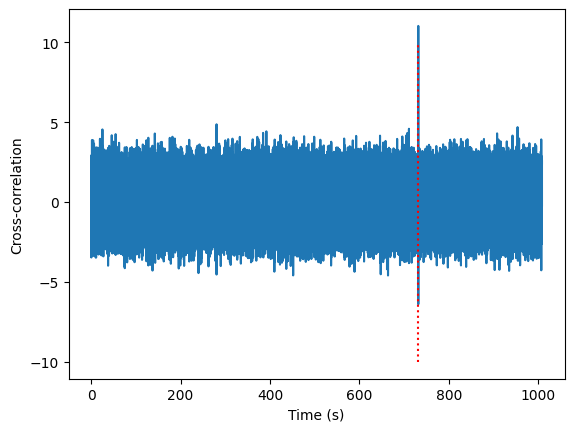

In [ ]:
# Initialize an array of zeros to store the cross-correlation results.
# The length is determined by the difference in lengths between the data and the signal.
cross_correlation = numpy.zeros([len(data)-len(hp1)])
# Convert the PyCBC TimeSeries object 'hp1' to a NumPy array for easier element-wise operations.
hp1_numpy = hp1.numpy()
# Loop through all possible starting positions for the signal within the data.
# The range ensures that the signal segment fits within the data.
for i in range(len(data) - len(hp1_numpy)):
    # Calculate the dot product (sum of element-wise products) of the signal with a segment of the data.
    # This performs the time-domain cross-correlation at each shift 'i'.
    cross_correlation[i] = (hp1_numpy * data[i:i+len(hp1_numpy)]).sum()

# plot the cross-correlated data vs time. Superimpose the location of the end of the signal;
# this is where we should find a peak in the cross-correlation.
plt.figure() # Create a new figure for plotting
# Create a time array for the cross-correlation results, matching its length and sample rate.
times = numpy.arange(len(data) - len(hp1_numpy)) / float(sample_rate)
plt.plot(times, cross_correlation) # Plot the calculated cross-correlation values over time
# Draw a vertical red dotted line ('r:') at the actual injection time of the signal.
# This helps visualize if the peak in cross-correlation aligns with the signal's true position.
plt.plot([waveform_start/float(sample_rate), waveform_start/float(sample_rate)], [-10,10],'r:')
plt.xlabel('Time (s)') # Set the label for the x-axis
plt.ylabel('Cross-correlation') # Set the label for the y-axis
plt.show() # Display the plot

### Detection in Colored Noise

Here you can see that the largest spike from the cross-correlation comes at the time of the signal. We only really need one more ingredient to describe matched-filtering: "Colored" noise (Gaussian noise but with a frequency-dependent variance; white noise has frequency-independent variance).

Let's repeat the process, but generate a stretch of data colored with LIGO's zero-detuned--high-power noise curve. We'll use the PyCBC library to do this.

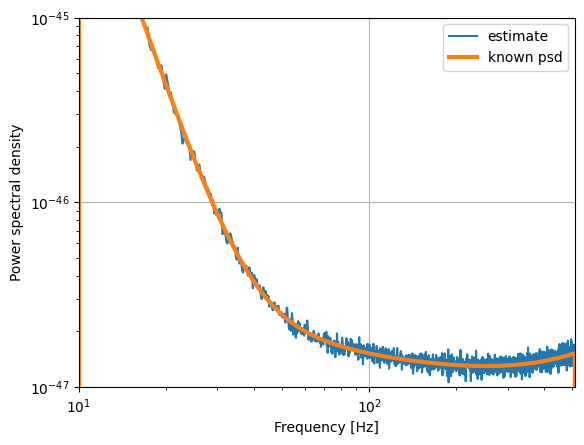

In [ ]:
# https://pycbc.org/pycbc/latest/html/noise.html
import pycbc.noise # Import the noise module from PyCBC for generating realistic noise
import pycbc.psd # Import the psd (Power Spectral Density) module from PyCBC for PSD functions

# The color of the noise matches a PSD which you provide:
# Generate a PSD matching Advanced LIGO's zero-detuned--high-power noise curve
flow = 10.0 # Define the lower frequency limit (Hz) for the PSD
delta_f = 1.0 / 128 # Define the frequency resolution (Hz) for the PSD
# Calculate the length of the frequency series (number of frequency bins) for the PSD.
# This is derived from the Nyquist frequency (sample_rate/2) and delta_f.
flen = int(sample_rate / (2 * delta_f)) + 1
# Generate a Power Spectral Density (PSD) model using a pre-defined Advanced LIGO noise curve.
psd = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f, flow)

# Generate colored noise
delta_t = 1.0 / sample_rate # Calculate the time step (seconds) between samples
# Generate a time series of colored noise based on the defined PSD, sample rate, and total data points.
ts = pycbc.noise.noise_from_psd(data_length*sample_rate, delta_t, psd, seed=127)

# Estimate the amplitude spectral density (ASD = sqrt(PSD)) for the noisy data
# using the "welch" method. We'll choose 4 seconds PSD samples that are overlapped 50%
seg_len = int(4 / delta_t) # Define the segment length (number of samples) for PSD estimation using Welch's method (4 seconds)
seg_stride = int(seg_len / 2) # Define the stride (overlap) for the segments in Welch's method (50% overlap)
# Estimate the PSD of the generated noisy data ('ts') using the Welch method.
estimated_psd = pycbc.psd.welch(ts,seg_len=seg_len,seg_stride=seg_stride)

# plot it:
# Plot the estimated PSD on a log-log scale.
plt.loglog(estimated_psd.sample_frequencies, estimated_psd, label='estimate')
# Plot the original (known) PSD for comparison, with a thicker line.
plt.loglog(psd.sample_frequencies, psd, linewidth=3, label='known psd')
plt.xlim(xmin=flow, xmax=512) # Set the x-axis limits for the plot (frequency range)
plt.ylim(1e-47, 1e-45) # Set the y-axis limits for the plot (PSD values)
plt.xlabel('Frequency [Hz]') # Set the x-axis label
plt.ylabel('Power spectral density') # Set the y-axis label
plt.legend() # Display the legend for the plot
plt.grid() # Add a grid to the plot for better readability
plt.show() # Display the plot

# add the signal, this time, with a "typical" amplitude.
# Add the signal (scaled to a realistic strain amplitude of 1E-20) into the generated colored noise ('ts').
ts[waveform_start:waveform_start+len(hp1)] += hp1.numpy() * 1E-20

Then all we need to do is to "whiten" both the data, and the template waveform. This can be done, in the frequency domain, by dividing by the PSD. This *can* be done in the time domain as well, but it's more intuitive in the frequency domain

In [ ]:
# Generate a PSD for whitening the data
from pycbc.types import TimeSeries # Import the TimeSeries object type from PyCBC for handling time series data

# The PSD, sampled properly for the noisy data
flow = 10.0 # Define the lower frequency limit (Hz) for the PSD
delta_f = 1.0 / data_length # Define the frequency resolution (Hz) for the PSD, based on the data length
# Calculate the length of the frequency series for the PSD, specific to the data length.
flen = int(sample_rate / (2 * delta_f)) + 1
# Generate a PSD model for the data, sampled appropriately. The '0' indicates no frequency shift.
psd_td = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f, 0)

# The PSD, sampled properly for the signal
delta_f = sample_rate / float(len(hp1)) # Define the frequency resolution for the PSD, specific to the signal length
# Calculate the length of the frequency series for the PSD, specific to the signal length.
flen = int(sample_rate / (2 * delta_f)) + 1
# Generate a PSD model for the signal, sampled appropriately.
psd_hp1 = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f, 0)

# The 0th and Nth values are zero. Set them to a nearby value to avoid dividing by zero.
# Set the first element of the data PSD to the second to avoid division by zero during whitening.
psd_td[0] = psd_td[1]
# Set the last element of the data PSD to the second-to-last to avoid division by zero.
psd_td[len(psd_td) - 1] = psd_td[len(psd_td) - 2]
# Same, for the PSD sampled for the signal
# Set the first element of the signal PSD to the second to avoid division by zero.
psd_hp1[0] = psd_hp1[1]
# Set the last element of the signal PSD to the second-to-last to avoid division by zero.
psd_hp1[len(psd_hp1) - 1] = psd_hp1[len(psd_hp1) - 2]

# convert both noisy data and the signal to frequency domain,
# and divide each by ASD=PSD**0.5, then convert back to time domain.
# This "whitens" the data and the signal template.
# Multiplying the signal template by 1E-21 puts it into realistic units of strain.
# Whitens the noisy data ('ts') by converting it to the frequency domain,
# dividing by the square root of its PSD (Amplitude Spectral Density),
# and then converting it back to the time domain.
data_whitened = (ts.to_frequencyseries() / psd_td**0.5).to_timeseries()
# Whitens the signal template ('hp1') using its specific PSD and scales it to a realistic strain amplitude.
hp1_whitened = (hp1.to_frequencyseries() / psd_hp1**0.5).to_timeseries() * 1E-21

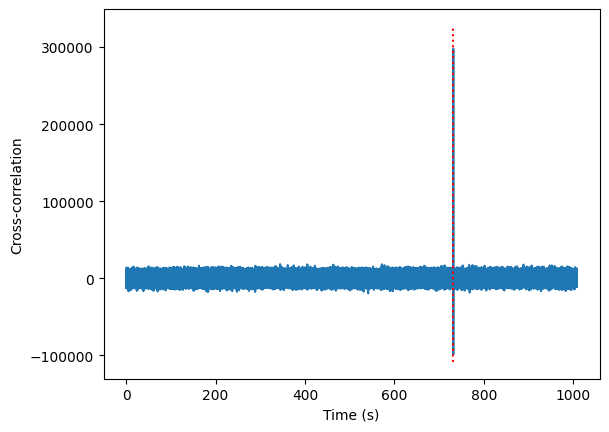

In [ ]:
# Now let's re-do the correlation, in the time domain, but with whitened data and template.
# Initialize a new array of zeros for the cross-correlation of the whitened data.
cross_correlation = numpy.zeros([len(datan)-len(hp1n)])
# Convert the whitened signal TimeSeries object ('hp1_whitened') to a NumPy array.
hp1n = hp1_whitened.numpy()
# Convert the whitened data TimeSeries object ('data_whitened') to a NumPy array.
datan = data_whitened.numpy()
# Loop through all possible starting positions for the whitened signal within the whitened data.
for i in range(len(datan) - len(hp1n)):
    # Calculate the time-domain cross-correlation between the whitened signal and whitened data segments.
    cross_correlation[i] = (hp1n * datan[i:i+len(hp1n)]).sum()

# plot the cross-correlation in the time domain. Superimpose the location of the end of the signal.
# Note how much bigger the cross-correlation peak is, relative to the noise level,
# compared with the unwhitened version of the same quantity. SNR is much higher!
plt.figure() # Create a new figure for plotting
# Create a time array for the whitened cross-correlation results, matching its length and sample rate.
times = numpy.arange(len(datan) - len(hp1n)) / float(sample_rate)
plt.plot(times, cross_correlation) # Plot the whitened cross-correlation values over time
# Draw a vertical red dotted line at the signal's original injection time.
# The y-limits are scaled to the min/max of the cross-correlation for better visibility of the line.
plt.plot([waveform_start/float(sample_rate), waveform_start/float(sample_rate)],
           [(min(cross_correlation))*1.1,(max(cross_correlation))*1.1],'r:')
plt.xlabel('Time (s)') # Set the x-axis label
plt.ylabel('Cross-correlation') # Set the y-axis label
plt.show() # Display the plot

## Quiz Questions

## Question 1

Histogram the whitened time series. Ignoring the outliers associated with the signal, is it a Gaussian? What is the mean and standard deviation? (We have not been careful in normalizing the whitened data properly).

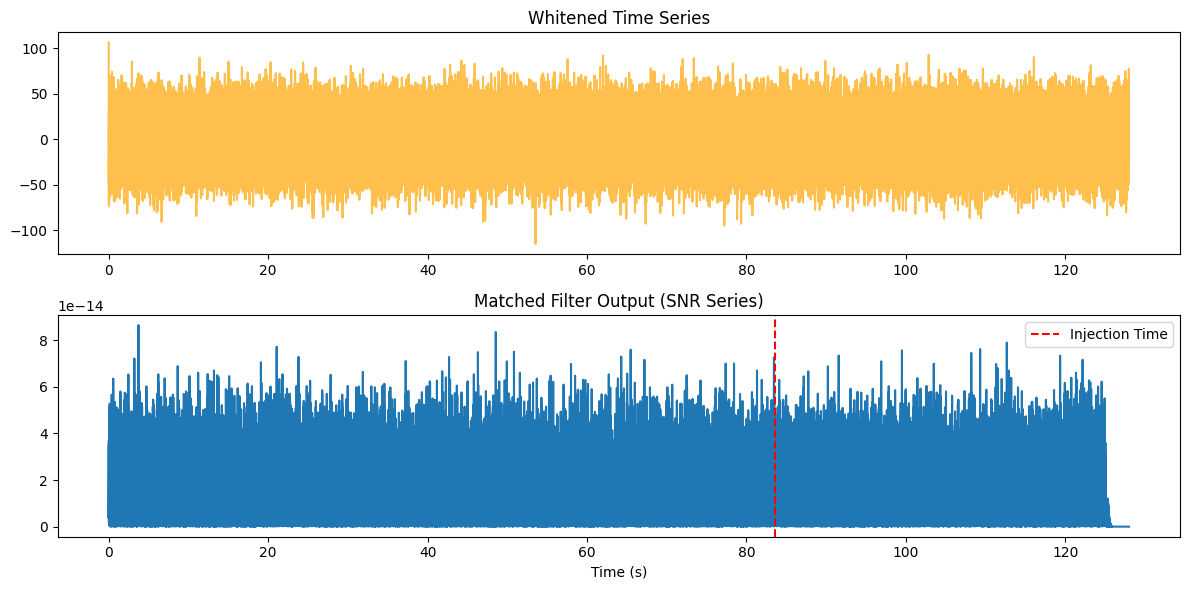

In [37]:
import pycbc.noise
import pycbc.psd
from pycbc.waveform import get_td_waveform
import numpy as np
import matplotlib.pyplot as plt
from pycbc.types import TimeSeries

sample_rate = 1024
data_length = 128

# 1. Setup the Analytical PSD model
flow = 10.0
delta_f = 1.0 / data_length
flen = int(sample_rate / (2 * delta_f)) + 1
psd = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f, flow)

# Fix boundaries and ensure no zeros to avoid division by zero
psd[0] = psd[1]
psd[len(psd) - 1] = psd[len(psd) - 2]
# Add a tiny epsilon to the entire PSD to guarantee positivity
psd.data[psd.data == 0] = psd[psd.data > 0].min()

# 2. Generate Noise and Inject Signal
delta_t = 1.0 / sample_rate
ts = pycbc.noise.noise_from_psd(data_length*sample_rate, delta_t, psd, seed=127)

# Generate the template (hp1)
hp1, _ = get_td_waveform(approximant='IMRPhenomD', mass1=30, mass2=30, delta_t=delta_t, f_lower=25)

# Inject signal at a random point
waveform_start = np.random.randint(0, len(ts) - len(hp1))
ts[waveform_start:waveform_start+len(hp1)] += hp1.numpy() * 1E-20

# 3. WHITENING
# Whiten the noisy data (ts)
data_whitened = (ts.to_frequencyseries() / psd**0.5).to_timeseries()

# To whiten the template (hp1), we need a PSD with matching frequency resolution
delta_f_hp1 = sample_rate / float(len(hp1))
flen_hp1 = int(sample_rate / (2 * delta_f_hp1)) + 1
psd_hp1 = pycbc.psd.aLIGOZeroDetHighPower(flen_hp1, delta_f_hp1, 20.0)
psd_hp1[0] = psd_hp1[1]
psd_hp1[len(psd_hp1)-1] = psd_hp1[len(psd_hp1)-2]
psd_hp1.data[psd_hp1.data == 0] = psd_hp1[psd_hp1.data > 0].min()

hp1_whitened = (hp1.to_frequencyseries() / psd_hp1**0.5).to_timeseries() * 1E-21

# 4. PERFORM MATCHED FILTERING (Cross-correlation)
datan = data_whitened.numpy()
hp1n = hp1_whitened.numpy()
snr_series = np.correlate(datan, hp1n, mode='same')

# Plotting results
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(data_whitened.sample_times, data_whitened, color='orange', alpha=0.7)
plt.title('Whitened Time Series')

plt.subplot(2, 1, 2)
plt.plot(data_whitened.sample_times, np.abs(snr_series))
plt.axvline(x=waveform_start/sample_rate, color='red', linestyle='--', label='Injection Time')
plt.title('Matched Filter Output (SNR Series)')
plt.xlabel('Time (s)')
plt.legend()

plt.tight_layout()
plt.show()

In [47]:
import pycbc.noise
import pycbc.psd
from pycbc.waveform import get_td_waveform
import numpy as np
import matplotlib.pyplot as plt
from pycbc.types import TimeSeries

sample_rate = 1024
data_length = 1024
flow = 10.0
delta_f = 1.0 / 128
flen = int(sample_rate / (2 * delta_f)) + 1

psd = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f, flow) #creates the

delta_t = 1.0 / sample_rate
ts = pycbc.noise.noise_from_psd(data_length*sample_rate, delta_t, psd, seed=127)

seg_len = int(4 / delta_t)
seg_stride = int(seg_len / 2)
estimated_psd = pycbc.psd.welch(ts,seg_len=seg_len,seg_stride=seg_stride)

hp1, _ = get_td_waveform(approximant='IMRPhenomD', # creates waveform
                         mass1=10,
                         mass2=10,
                         delta_t=1.0/sample_rate,
                         f_lower=25)

hp1 = hp1 / max(numpy.correlate(hp1, hp1, mode='full'))**0.5

ts[waveform_start:waveform_start+len(hp1)] += hp1.numpy() * 1E-20 # adds waveform

#WHITENING
flow = 10.0
delta_f = 1.0 / data_length
flen = int(sample_rate / (2 * delta_f)) + 1
psd_td = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f, 0)

delta_f = sample_rate / float(len(hp1))
flen = int(sample_rate / (2 * delta_f)) + 1
psd_hp1 = pycbc.psd.aLIGOZeroDetHighPower(flen, delta_f, 0)

psd_td[0] = psd_td[1]
psd_td[len(psd_td) - 1] = psd_td[len(psd_td) - 2]

# Same, for the PSD sampled for the signal
psd_hp1[0] = psd_hp1[1]
psd_hp1[len(psd_hp1) - 1] = psd_hp1[len(psd_hp1) - 2]

data_whitened = (ts.to_frequencyseries() / psd_td**0.5).to_timeseries()
hp1_whitened = (hp1.to_frequencyseries() / psd_hp1**0.5).to_timeseries() * 1E-21

#CROSS CORRELATION
cross_correlation = numpy.zeros([len(data)-len(hp1)])
hp1n = hp1_whitened.numpy()
datan = data_whitened.numpy()
for i in range(len(datan) - len(hp1n)):
    cross_correlation[i] = (hp1n * datan[i:i+len(hp1n)]).sum()

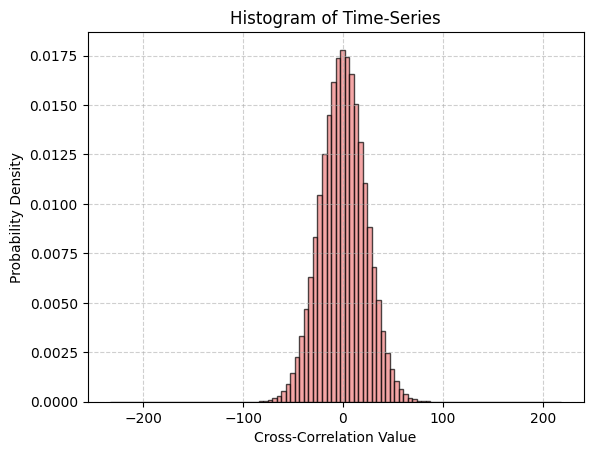

Mean: 2.3469453377250593e-15
Standard Deviation: 22.475078945312465


In [50]:
plt.hist(data_whitened, bins=100, density=True, alpha=0.7, color='lightcoral', edgecolor='black') # Plot the histogram
plt.title('Histogram of Time-Series') # Set the title
plt.xlabel('Cross-Correlation Value') # Set the x-axis label
plt.ylabel('Probability Density') # Set the y-axis label
plt.grid(True, linestyle='--', alpha=0.6) # Add a grid
plt.show()
print(f"Mean: {np.mean(data_whitened)}")
print(f"Standard Deviation: {np.std(data_whitened)}")

In [ ]:
Data and template have been whitened successfully.

## Question 2

Histogram the above cross-correlation time series. Ignoring the outliers associated with the signal, is it a Gaussian? What is the mean and standard deviation?

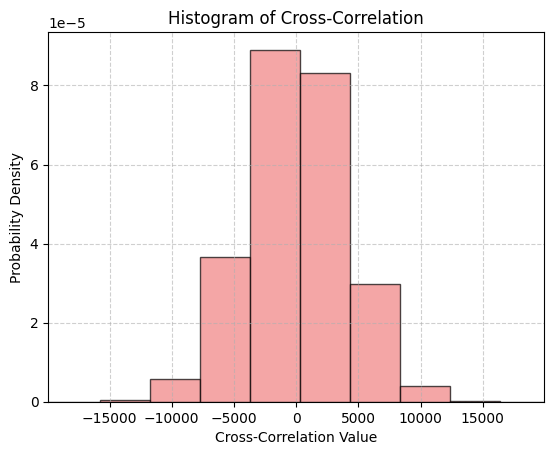

Mean: -0.0065
Standard Deviation: 3987.1756


In [54]:
plt.hist(cross_correlation, bins=100, density=True, alpha=0.7, color='lightcoral', edgecolor='black')
plt.title('Histogram of Cross-Correlation')
plt.xlabel('Cross-Correlation Value')
plt.ylabel('Probability Density')
plt.grid(True, linestyle='--', alpha=0.6)

# Dynamic limits: zoom in to +/- 5 standard deviations
mu = np.mean(cross_correlation)
sigma = np.std(cross_correlation)
plt.xlim(mu - 5*sigma, mu + 5*sigma)

plt.show()

print(f"Mean: {mu:.4f}")
print(f"Standard Deviation: {sigma:.4f}")

## Question 3 (Optional)

Find the location of the peak. (Note that here, it can be positive or negative), and the value of the SNR of the signal (which is the absolute value of the peak value, divided by the standard deviation of the cross-correlation time series).